<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); padding: 40px; border-radius: 10px; margin-bottom: 20px;">
<h1 style="color: white; margin: 0; font-size: 2.5em;">Lecture 14: SCE Accelerator Architecture</h1>
<p style="color: #888; font-size: 1.2em; margin-top: 10px;">Part IV: Applications — SCE Futures</p>
</div>

## Table of Contents

1. [From Transformers to Hardware](#transformers-to-hardware)
2. [What is a Systolic Array?](#systolic-array-basics)
3. [Matrix Multiplication on Systolic Arrays](#matmul-systolic)
4. [Google TPU Architecture](#tpu-architecture)
5. [Tiling Large Matrices](#tiling-strategies)
6. [Data Movement Analysis](#data-movement)
7. [Memory Hierarchy and Data Reuse](#memory-hierarchy)
8. [Mapping Transformers to Systolic Arrays](#mapping-transformers)
9. [Why Superconducting Logic?](#why-superconducting)
10. [Summary](#summary)

## Learning Objectives

By the end of this lecture, you will be able to:

- Explain the systolic array architecture and why it's efficient for matrix operations
- Trace data flow through a systolic array during matrix multiplication
- Calculate how large matrices are tiled to fit on finite hardware
- Quantify data movement: bytes read from memory vs. bytes produced
- Analyze arithmetic intensity and identify memory vs. compute bottlenecks
- Map transformer operations (attention, FFN) to systolic array execution
- Understand why the memory wall motivates novel architectures like superconducting logic

---

<a id='transformers-to-hardware'></a>
## 1. From Transformers to Hardware

In the previous lecture, we established that transformers are fundamentally composed of:

1. **Matrix-matrix multiplications** (attention projections, FFN layers)
2. **Matrix-vector multiplications** (inference with batch=1)
3. **Element-wise operations** (activations, layer norm)
4. **Softmax** (attention weights)

The dominant operations are **GEMMs** (General Matrix-Matrix Multiplies), which account for >90% of compute.

### The Hardware Design Question

How do we build hardware that efficiently executes millions of these matrix operations?

**Options:**

| Architecture | Strengths | Weaknesses |
|--------------|-----------|------------|
| **CPU** | Flexible, large cache | Low parallelism, poor FLOP/W |
| **GPU** | Massive parallelism | Complex memory hierarchy, power-hungry |
| **Systolic Array** | High efficiency, simple design | Fixed dataflow, limited flexibility |
| **FPGA** | Reconfigurable | Lower performance, complex tooling |

Systolic arrays have emerged as the architecture of choice for inference accelerators, used in:
- Google TPU (Tensor Processing Unit)
- Apple Neural Engine
- Many inference ASICs

In [1]:
# Setup: Import libraries for visualizations
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyArrowPatch
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import numpy as np

COLORS = {
    'primary': '#2196F3',           # Blue
    'secondary': '#FF9800',         # Orange
    'success': '#4CAF50',           # Green
    'danger': '#f44336',            # Red
    'dark': '#1a1a2e',              # Dark navy
    'light': '#f5f5f5',             # Light gray
    'purple': '#9C27B0',            # Purple
    'cyan': '#00BCD4',              # Cyan
    'weight': '#E91E63',            # Pink for weights
    'activation': '#3F51B5',        # Indigo for activations
    'accumulator': '#009688',       # Teal for accumulators
    'pe': '#FFC107',                # Amber for processing elements
}

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.size'] = 11

print("Setup complete.")

Setup complete.


---

<a id='systolic-array-basics'></a>
## 2. What is a Systolic Array?

A **systolic array** is a network of processing elements (PEs) arranged in a regular grid, where data flows rhythmically through the array like blood through the circulatory system (hence "systolic").

### Key Characteristics

1. **Regular structure**: 2D grid of identical PEs
2. **Local communication**: Each PE only talks to immediate neighbors
3. **Pipelined execution**: Data flows continuously through the array
4. **High data reuse**: Each value is used multiple times as it flows

### Processing Element (PE)

Each PE performs a simple operation:

```
accumulator += input_A × input_B
pass input_A to right neighbor
pass input_B to bottom neighbor
```

This is the **multiply-accumulate (MAC)** operation, the fundamental building block of matrix multiplication.

### Why Systolic Arrays are Efficient

1. **Minimal memory access**: Data is fetched once, used many times
2. **No global interconnect**: Only local wires between neighbors
3. **Simple control**: All PEs execute the same instruction
4. **High utilization**: Once filled, every PE is computing every cycle

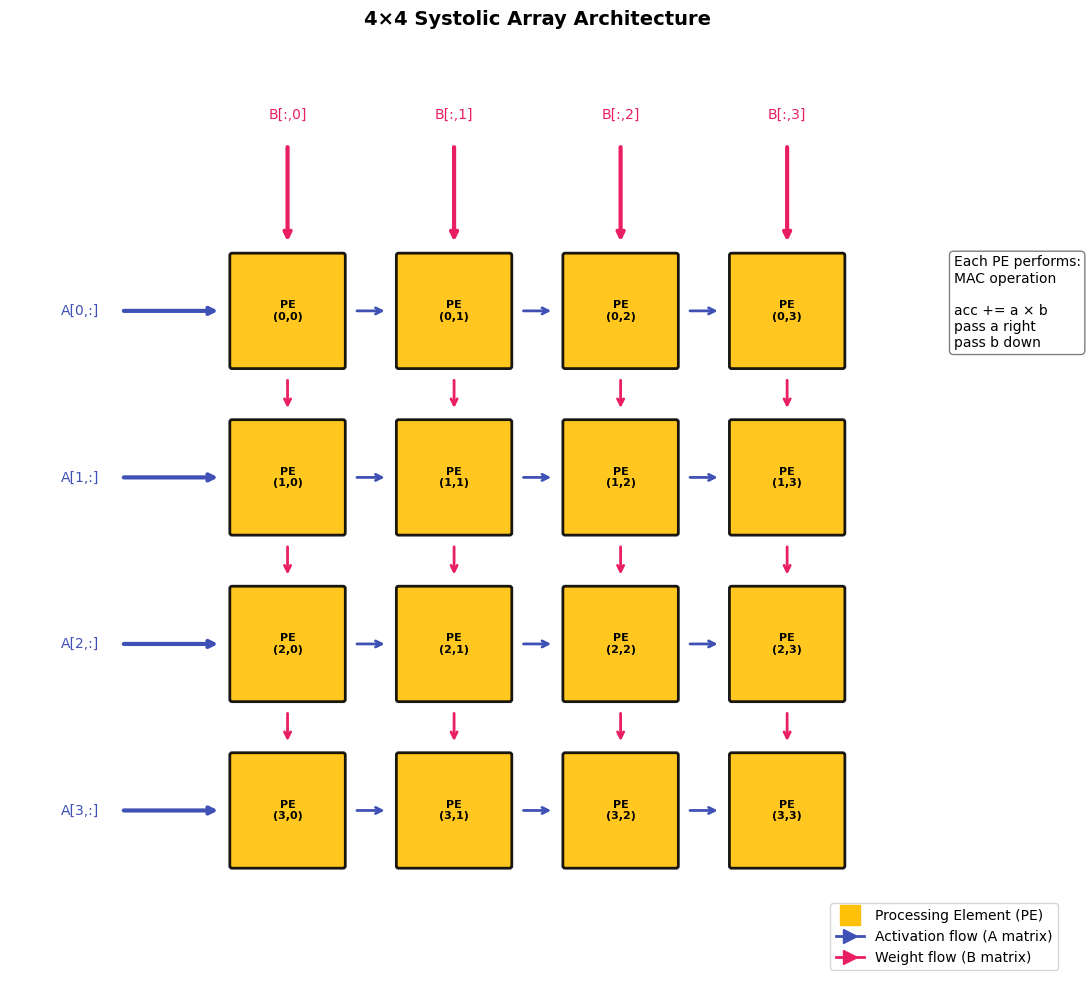

A 4×4 systolic array has 16 = 16 PEs
Each cycle, it performs 16 MAC operations = 32 FLOPs
TPU v4 has 128×128 = 16,384 PEs!


In [2]:
# Visualize: Basic systolic array structure
fig, ax = plt.subplots(figsize=(12, 10))

n = 4  # 4x4 array
pe_size = 1.0
spacing = 1.5

# Draw PEs
for i in range(n):
    for j in range(n):
        x = j * spacing + 2
        y = (n - 1 - i) * spacing + 1
        
        # PE box
        pe = patches.FancyBboxPatch((x - pe_size/2, y - pe_size/2), pe_size, pe_size,
                                     boxstyle="round,pad=0.02",
                                     facecolor=COLORS['pe'], alpha=0.9,
                                     edgecolor='black', linewidth=2)
        ax.add_patch(pe)
        ax.text(x, y, f'PE\n({i},{j})', ha='center', va='center', fontsize=8, fontweight='bold')
        
        # Horizontal arrows (right) - for A matrix
        if j < n - 1:
            ax.annotate('', xy=(x + spacing - pe_size/2 - 0.1, y),
                        xytext=(x + pe_size/2 + 0.1, y),
                        arrowprops=dict(arrowstyle='->', color=COLORS['activation'], lw=2))
        
        # Vertical arrows (down) - for B matrix
        if i < n - 1:
            ax.annotate('', xy=(x, y - spacing + pe_size/2 + 0.1),
                        xytext=(x, y - pe_size/2 - 0.1),
                        arrowprops=dict(arrowstyle='->', color=COLORS['weight'], lw=2))

# Input labels - A matrix (left side)
for i in range(n):
    y = (n - 1 - i) * spacing + 1
    ax.annotate('', xy=(2 - pe_size/2 - 0.1, y),
                xytext=(0.5, y),
                arrowprops=dict(arrowstyle='->', color=COLORS['activation'], lw=3))
    ax.text(0.3, y, f'A[{i},:]', ha='right', va='center', fontsize=10, color=COLORS['activation'])

# Input labels - B matrix (top)
for j in range(n):
    x = j * spacing + 2
    ax.annotate('', xy=(x, (n-1) * spacing + 1 + pe_size/2 + 0.1),
                xytext=(x, (n-1) * spacing + 2.5),
                arrowprops=dict(arrowstyle='->', color=COLORS['weight'], lw=3))
    ax.text(x, (n-1) * spacing + 2.7, f'B[:,{j}]', ha='center', va='bottom', fontsize=10, color=COLORS['weight'])

# Legend
ax.plot([], [], 's', markersize=15, color=COLORS['pe'], label='Processing Element (PE)')
ax.plot([], [], '->', markersize=10, color=COLORS['activation'], label='Activation flow (A matrix)', linewidth=2)
ax.plot([], [], '->', markersize=10, color=COLORS['weight'], label='Weight flow (B matrix)', linewidth=2)
ax.legend(loc='lower right', fontsize=10)

# Title and labels
ax.set_xlim(-0.5, 9)
ax.set_ylim(-0.5, 8)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title(f'{n}×{n} Systolic Array Architecture', fontsize=14, fontweight='bold')

# Annotations
ax.text(8, 6, 'Each PE performs:\nMAC operation\n\nacc += a × b\npass a right\npass b down', 
        fontsize=10, va='top', ha='left',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray'))

plt.tight_layout()
plt.show()

print(f"A {n}×{n} systolic array has {n*n} = {n**2} PEs")
print(f"Each cycle, it performs {n**2} MAC operations = {2*n**2} FLOPs")
print(f"TPU v4 has 128×128 = 16,384 PEs!")

---

<a id='matmul-systolic'></a>
## 3. Matrix Multiplication on Systolic Arrays

Consider multiplying matrices: $C = A \times B$

Where:
- $A$ is $M \times K$
- $B$ is $K \times N$  
- $C$ is $M \times N$

### The Algorithm

For a $P \times P$ systolic array computing a $P \times P$ output:

1. **Setup**: Each PE initializes its accumulator to 0
2. **Stream A rows** from the left, staggered by one cycle per row
3. **Stream B columns** from the top, staggered by one cycle per column
4. **Each cycle**: Every PE multiplies its inputs and adds to its accumulator
5. **After K+2P-2 cycles**: All results are computed

### The Magic: Data Reuse

Each element of A is used P times (once per column of B).
Each element of B is used P times (once per row of A).

**Total data read**: $P \times K$ (for A) + $K \times P$ (for B) = $2PK$ elements

**Total compute**: $2P^2K$ FLOPs (P² outputs, each requiring K multiply-adds)

**Arithmetic intensity** = $\frac{2P^2K}{2PK \times \text{bytes/elem}} = \frac{P}{\text{bytes/elem}}$

For a 128×128 array with FP16: intensity = 128/2 = **64 FLOPs/byte**

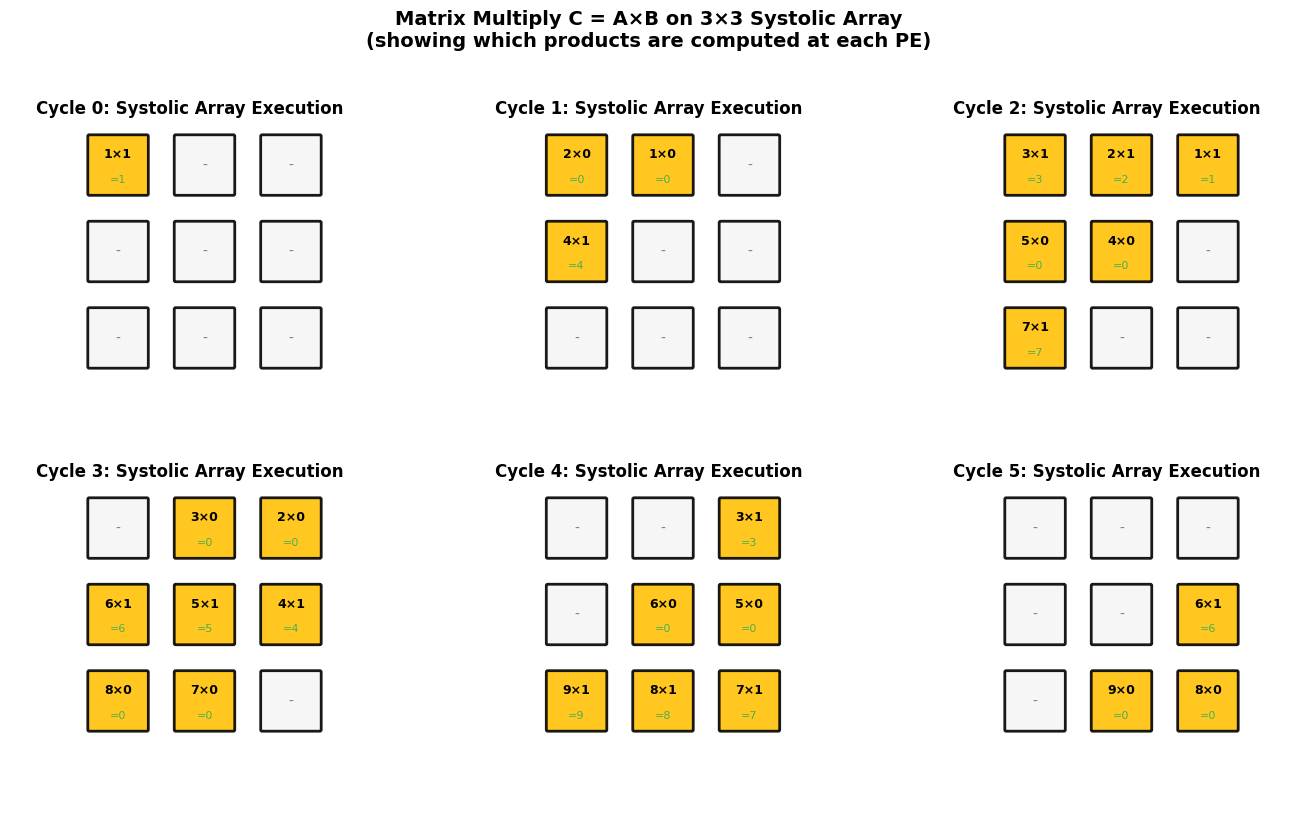

Cycle 0: Only PE(0,0) is active
Cycle 1: Diagonal PE(0,1) and PE(1,0) become active
Cycle 2: All PEs on main anti-diagonal active
...
After cycle 4: All partial products computed, accumulators contain final results


In [3]:
# Visualize: Step-by-step matrix multiplication on a 3x3 systolic array
# We'll show how data flows through to compute C = A × B

def visualize_systolic_step(ax, step, n=3, k=3):
    """Visualize one step of systolic array execution."""
    ax.clear()
    
    pe_size = 0.8
    spacing = 1.2
    
    # Example matrices
    A = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
    B = np.array([[1, 0, 1], [0, 1, 0], [1, 0, 1]])
    
    # Track which data is at each PE at this step
    # Data arrives staggered: row i arrives at time i, col j arrives at time j
    
    for i in range(n):
        for j in range(n):
            x = j * spacing + 1.5
            y = (n - 1 - i) * spacing + 1
            
            # Calculate what's at this PE
            # A element from row i arrives at column j at time (i + j)
            # The k-th element of row i arrives at time (i + k)
            # At column j, we see the (step - i - j)th element
            k_idx = step - i - j
            
            if 0 <= k_idx < k:
                a_val = A[i, k_idx]
                b_val = B[k_idx, j]
                active = True
            else:
                a_val = None
                b_val = None
                active = False
            
            # PE box
            color = COLORS['pe'] if active else COLORS['light']
            pe = patches.FancyBboxPatch((x - pe_size/2, y - pe_size/2), pe_size, pe_size,
                                         boxstyle="round,pad=0.02",
                                         facecolor=color, alpha=0.9,
                                         edgecolor='black', linewidth=2)
            ax.add_patch(pe)
            
            # Show values
            if active:
                ax.text(x, y + 0.15, f'{a_val}×{b_val}', ha='center', va='center', fontsize=9, fontweight='bold')
                ax.text(x, y - 0.2, f'={a_val*b_val}', ha='center', va='center', fontsize=8, color=COLORS['success'])
            else:
                ax.text(x, y, '-', ha='center', va='center', fontsize=10, color='gray')
    
    # Title
    ax.set_title(f'Cycle {step}: Systolic Array Execution', fontsize=12, fontweight='bold')
    ax.set_xlim(0, 5)
    ax.set_ylim(-0.5, 4)
    ax.set_aspect('equal')
    ax.axis('off')

# Create figure showing multiple time steps
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for idx, step in enumerate([0, 1, 2, 3, 4, 5]):
    ax = axes[idx // 3, idx % 3]
    visualize_systolic_step(ax, step)

plt.suptitle('Matrix Multiply C = A×B on 3×3 Systolic Array\n(showing which products are computed at each PE)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Cycle 0: Only PE(0,0) is active")
print("Cycle 1: Diagonal PE(0,1) and PE(1,0) become active")
print("Cycle 2: All PEs on main anti-diagonal active")
print("...")
print("After cycle 4: All partial products computed, accumulators contain final results")

In [4]:
# Calculate: Timing and efficiency of systolic array execution

def systolic_analysis(P, K, clock_freq_ghz=1.0, dtype_bytes=2):
    """Analyze systolic array performance for P×P array computing P×K × K×P matmul."""
    
    # Timing
    fill_cycles = P - 1  # Time to fill the array
    compute_cycles = K   # Time to stream all K elements
    drain_cycles = P - 1 # Time to drain results
    total_cycles = fill_cycles + compute_cycles + drain_cycles
    
    # Alternative: overlapped execution (steady state)
    steady_state_cycles = K  # In steady state, just K cycles
    
    # Compute
    total_macs = P * P * K
    total_flops = 2 * total_macs
    
    # Data movement (assuming each element read once from external memory)
    a_bytes = P * K * dtype_bytes  # A matrix
    b_bytes = K * P * dtype_bytes  # B matrix
    c_bytes = P * P * dtype_bytes  # C matrix (output)
    total_bytes_in = a_bytes + b_bytes
    total_bytes_out = c_bytes
    
    # Arithmetic intensity
    arithmetic_intensity = total_flops / (total_bytes_in + total_bytes_out)
    
    # Utilization
    # Maximum possible: P² MACs per cycle
    peak_macs = P * P * total_cycles
    utilization = total_macs / peak_macs
    
    # Steady state utilization (after warmup)
    steady_utilization = total_macs / (P * P * K)
    
    # Performance
    time_ns = total_cycles / clock_freq_ghz
    tflops = total_flops / (time_ns * 1e-9) / 1e12
    
    return {
        'total_cycles': total_cycles,
        'steady_cycles': steady_state_cycles,
        'total_flops': total_flops,
        'bytes_in': total_bytes_in,
        'bytes_out': total_bytes_out,
        'arithmetic_intensity': arithmetic_intensity,
        'utilization': utilization,
        'steady_utilization': steady_utilization,
        'time_ns': time_ns,
        'tflops': tflops,
    }

print("="*70)
print("SYSTOLIC ARRAY PERFORMANCE ANALYSIS")
print("="*70)

configs = [
    (4, 4, "Tiny (4×4)"),
    (16, 64, "Small (16×16)"),
    (128, 128, "TPU v2/v3 (128×128)"),
    (128, 4096, "TPU with d_model=4096"),
]

for P, K, name in configs:
    stats = systolic_analysis(P, K)
    print(f"\n{name}: {P}×{P} array, K={K}")
    print(f"  Cycles: {stats['total_cycles']} total ({P-1} fill + {K} compute + {P-1} drain)")
    print(f"  FLOPs: {stats['total_flops']:,} ({stats['total_flops']/1e6:.2f}M)")
    print(f"  Data: {stats['bytes_in']/1024:.1f} KB in, {stats['bytes_out']/1024:.1f} KB out")
    print(f"  Arithmetic intensity: {stats['arithmetic_intensity']:.1f} FLOPs/byte")
    print(f"  Utilization: {stats['utilization']*100:.1f}% (amortized) / {stats['steady_utilization']*100:.1f}% (steady)")

SYSTOLIC ARRAY PERFORMANCE ANALYSIS

Tiny (4×4): 4×4 array, K=4
  Cycles: 10 total (3 fill + 4 compute + 3 drain)
  FLOPs: 128 (0.00M)
  Data: 0.1 KB in, 0.0 KB out
  Arithmetic intensity: 1.3 FLOPs/byte
  Utilization: 40.0% (amortized) / 100.0% (steady)

Small (16×16): 16×16 array, K=64
  Cycles: 94 total (15 fill + 64 compute + 15 drain)
  FLOPs: 32,768 (0.03M)
  Data: 4.0 KB in, 0.5 KB out
  Arithmetic intensity: 7.1 FLOPs/byte
  Utilization: 68.1% (amortized) / 100.0% (steady)

TPU v2/v3 (128×128): 128×128 array, K=128
  Cycles: 382 total (127 fill + 128 compute + 127 drain)
  FLOPs: 4,194,304 (4.19M)
  Data: 64.0 KB in, 32.0 KB out
  Arithmetic intensity: 42.7 FLOPs/byte
  Utilization: 33.5% (amortized) / 100.0% (steady)

TPU with d_model=4096: 128×128 array, K=4096
  Cycles: 4350 total (127 fill + 4096 compute + 127 drain)
  FLOPs: 134,217,728 (134.22M)
  Data: 2048.0 KB in, 32.0 KB out
  Arithmetic intensity: 63.0 FLOPs/byte
  Utilization: 94.2% (amortized) / 100.0% (steady)


---

<a id='tpu-architecture'></a>
## 4. Google TPU Architecture

The **Tensor Processing Unit (TPU)** is Google's custom ASIC for machine learning, built around a large systolic array.

### TPU v1 (2016) - Inference Only

| Component | Specification |
|-----------|---------------|
| Systolic array | 256 × 256 = 65,536 MACs |
| Clock speed | 700 MHz |
| Peak performance | 92 TOPS (INT8) |
| On-chip memory | 28 MB |
| Memory bandwidth | 34 GB/s (DDR3) |
| Power | 40W |

### TPU v4 (2021) - Training and Inference

| Component | Specification |
|-----------|---------------|
| Systolic arrays | 2 × (128 × 128) = 32,768 MACs |
| Clock speed | ~1.1 GHz |
| Peak performance | 275 TFLOPS (BF16) |
| HBM capacity | 32 GB |
| Memory bandwidth | 1.2 TB/s |
| Power | ~200W |

### Architecture Diagram

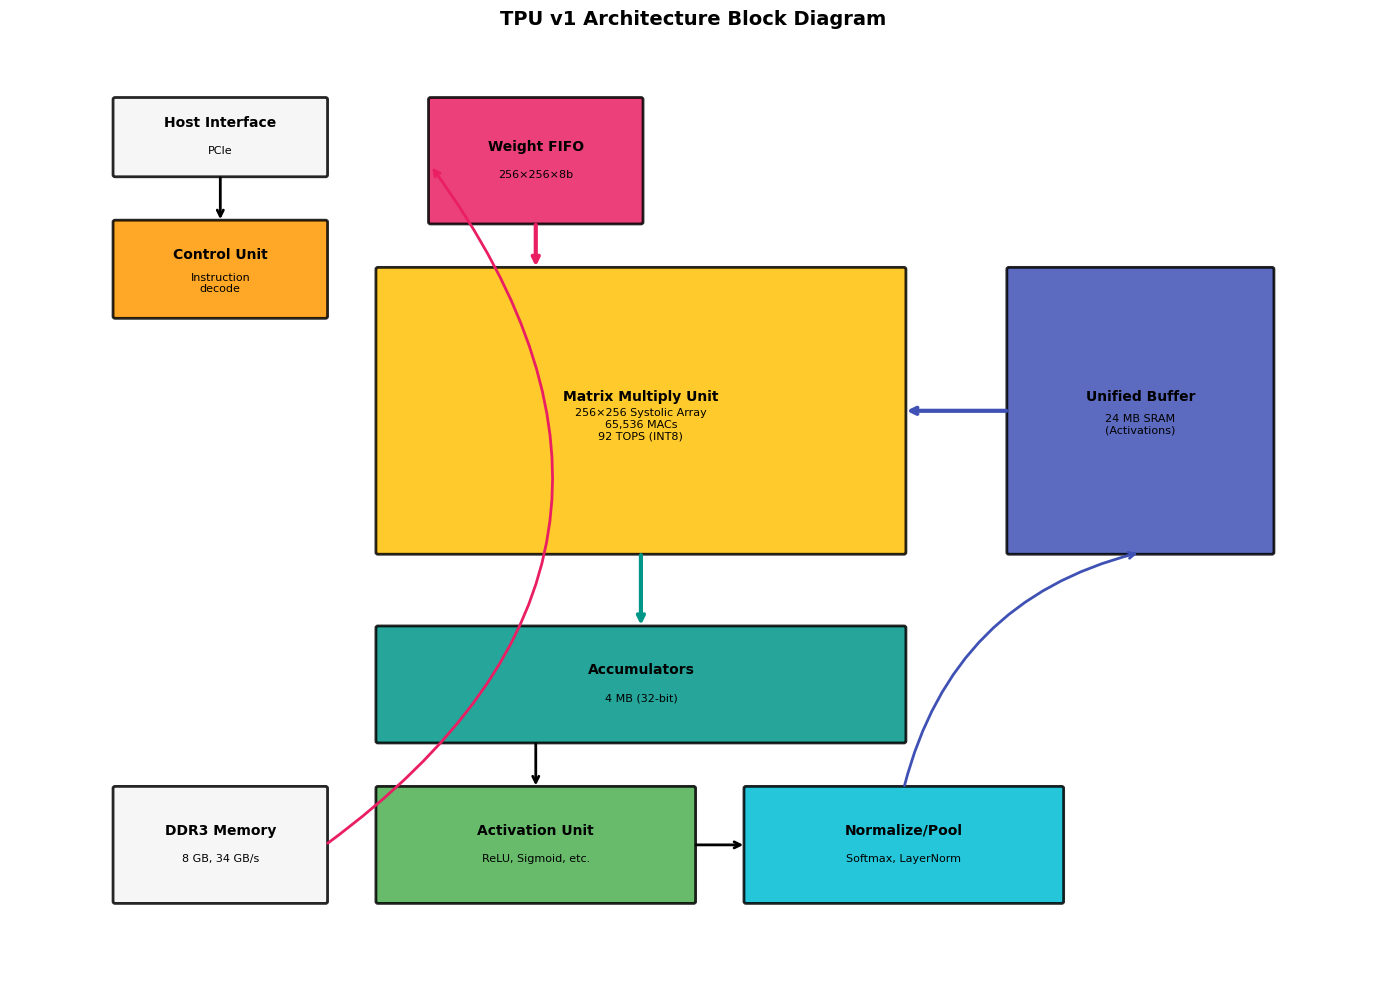

Key insight: The systolic array (MMU) is the heart of the TPU.
All other components exist to feed it data and handle results.
TPU design philosophy: Maximize utilization of the matrix multiply unit.


In [5]:
# Visualize: TPU architecture block diagram
fig, ax = plt.subplots(figsize=(14, 10))

def draw_component(ax, x, y, w, h, label, color, sublabel=''):
    rect = patches.FancyBboxPatch((x, y), w, h,
                                   boxstyle="round,pad=0.02",
                                   facecolor=color, alpha=0.85,
                                   edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    if sublabel:
        ax.text(x + w/2, y + h/2 + 0.15, label, ha='center', va='center', 
                fontsize=10, fontweight='bold')
        ax.text(x + w/2, y + h/2 - 0.15, sublabel, ha='center', va='center', fontsize=8)
    else:
        ax.text(x + w/2, y + h/2, label, ha='center', va='center', 
                fontsize=10, fontweight='bold')

# Host interface
draw_component(ax, 0.5, 8, 2, 0.8, 'Host Interface', COLORS['light'], 'PCIe')

# Control
draw_component(ax, 0.5, 6.5, 2, 1, 'Control Unit', COLORS['secondary'], 'Instruction\ndecode')

# Weight FIFO
draw_component(ax, 3.5, 7.5, 2, 1.3, 'Weight FIFO', COLORS['weight'], '256×256×8b')

# Matrix Multiply Unit (main systolic array)
draw_component(ax, 3, 4, 5, 3, 'Matrix Multiply Unit', COLORS['pe'], '256×256 Systolic Array\n65,536 MACs\n92 TOPS (INT8)')

# Unified Buffer
draw_component(ax, 9, 4, 2.5, 3, 'Unified Buffer', COLORS['activation'], '24 MB SRAM\n(Activations)')

# Accumulators
draw_component(ax, 3, 2, 5, 1.2, 'Accumulators', COLORS['accumulator'], '4 MB (32-bit)')

# Activation Unit
draw_component(ax, 3, 0.3, 3, 1.2, 'Activation Unit', COLORS['success'], 'ReLU, Sigmoid, etc.')

# Normalize/Pool
draw_component(ax, 6.5, 0.3, 3, 1.2, 'Normalize/Pool', COLORS['cyan'], 'Softmax, LayerNorm')

# DDR Memory
draw_component(ax, 0.5, 0.3, 2, 1.2, 'DDR3 Memory', COLORS['light'], '8 GB, 34 GB/s')

# Arrows showing data flow
# Host to Control
ax.annotate('', xy=(1.5, 7.5), xytext=(1.5, 8), arrowprops=dict(arrowstyle='->', color='black', lw=2))

# Weight FIFO to MMU
ax.annotate('', xy=(4.5, 7), xytext=(4.5, 7.5), arrowprops=dict(arrowstyle='->', color=COLORS['weight'], lw=3))

# Unified Buffer to MMU
ax.annotate('', xy=(8, 5.5), xytext=(9, 5.5), arrowprops=dict(arrowstyle='->', color=COLORS['activation'], lw=3))

# MMU to Accumulators
ax.annotate('', xy=(5.5, 3.2), xytext=(5.5, 4), arrowprops=dict(arrowstyle='->', color=COLORS['accumulator'], lw=3))

# Accumulators to Activation
ax.annotate('', xy=(4.5, 1.5), xytext=(4.5, 2), arrowprops=dict(arrowstyle='->', color='black', lw=2))

# Activation to Normalize
ax.annotate('', xy=(6.5, 0.9), xytext=(6, 0.9), arrowprops=dict(arrowstyle='->', color='black', lw=2))

# Normalize back to Unified Buffer
ax.annotate('', xy=(10.25, 4), xytext=(8, 1.5), 
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=-0.3', color=COLORS['activation'], lw=2))

# DDR to Weight FIFO
ax.annotate('', xy=(3.5, 8.1), xytext=(2.5, 0.9), 
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.5', color=COLORS['weight'], lw=2))

ax.set_xlim(-0.5, 12.5)
ax.set_ylim(-0.5, 9.5)
ax.axis('off')
ax.set_title('TPU v1 Architecture Block Diagram', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("Key insight: The systolic array (MMU) is the heart of the TPU.")
print("All other components exist to feed it data and handle results.")
print("TPU design philosophy: Maximize utilization of the matrix multiply unit.")

---

<a id='tiling-strategies'></a>
## 5. Tiling Large Matrices

Real transformer matrices are much larger than any systolic array:

| Matrix | Typical Size | vs 128×128 Array |
|--------|--------------|------------------|
| $W_Q$ in Llama 7B | 4096 × 4096 | 32 × 32 = 1024 tiles |
| FFN up in Llama 7B | 4096 × 11008 | 32 × 86 = 2752 tiles |
| Attention scores (8K ctx) | 8192 × 8192 | 64 × 64 = 4096 tiles |

### Tiling Strategy

To compute $C = A \times B$ where all matrices exceed array size:

1. **Partition** A into row-blocks of size P
2. **Partition** B into column-blocks of size P  
3. **Partition** the K dimension into blocks of size K_tile
4. **Accumulate** partial results across K-tiles

$$C[i:i+P, j:j+P] = \sum_{k=0}^{K/K_{tile}-1} A[i:i+P, k \cdot K_{tile}:(k+1) \cdot K_{tile}] \times B[k \cdot K_{tile}:(k+1) \cdot K_{tile}, j:j+P]$$

### Tiling Trade-offs

| Factor | Smaller Tiles | Larger Tiles |
|--------|---------------|---------------|
| On-chip memory | Less required | More required |
| Data reuse | Lower | Higher |
| Memory bandwidth | Higher pressure | Lower pressure |
| Fill/drain overhead | Higher | Lower |

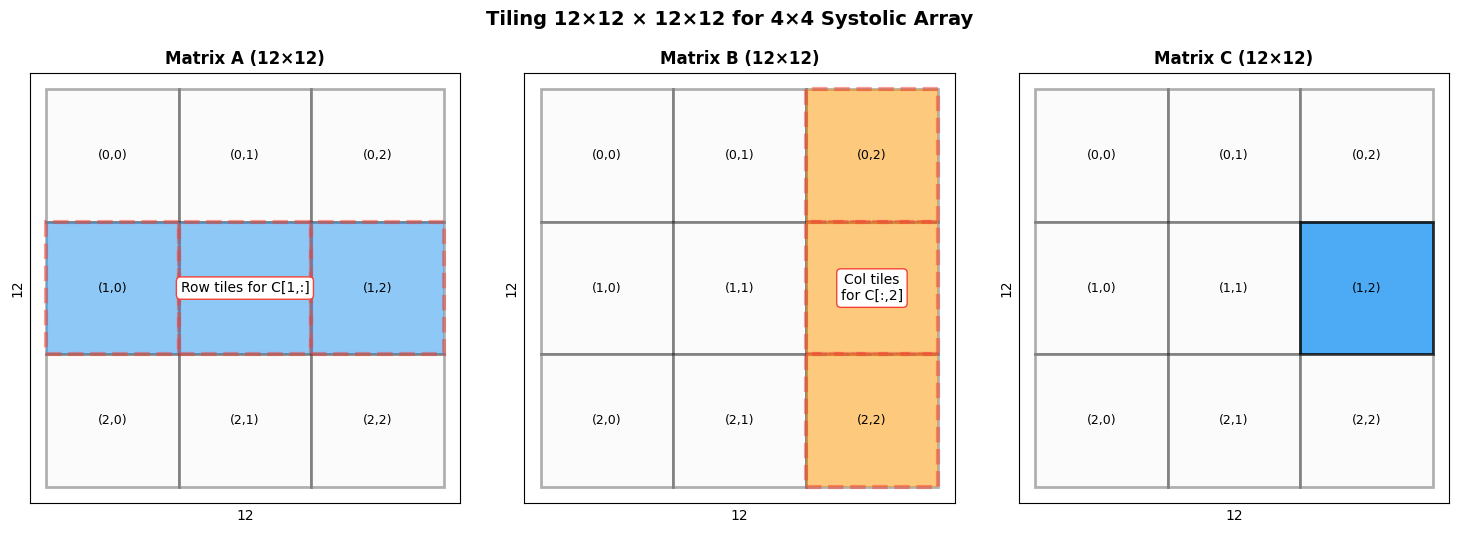


To compute full C matrix:
  Output tiles: 3 × 3 = 9 tiles
  K-dimension tiles: 3
  Total tile operations: 27
  Each tile: 4×4×4 = 64 MACs
  Total MACs: 1,728 = 1,728 (matches M×N×K)


In [6]:
# Visualize: Tiling a large matrix multiply
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Example: 12×12 matrices tiled for 4×4 systolic array
M, N, K = 12, 12, 12
P = 4  # Tile size (array size)

def draw_tiled_matrix(ax, rows, cols, tile_size, title, highlight_tile=None):
    """Draw a matrix with tile boundaries."""
    ax.set_xlim(-0.5, cols + 0.5)
    ax.set_ylim(-0.5, rows + 0.5)
    
    # Draw tiles
    n_row_tiles = rows // tile_size
    n_col_tiles = cols // tile_size
    
    for i in range(n_row_tiles):
        for j in range(n_col_tiles):
            x = j * tile_size
            y = rows - (i + 1) * tile_size
            
            is_highlighted = (highlight_tile is not None and 
                            highlight_tile[0] == i and highlight_tile[1] == j)
            
            color = COLORS['primary'] if is_highlighted else COLORS['light']
            alpha = 0.8 if is_highlighted else 0.3
            
            rect = patches.Rectangle((x, y), tile_size, tile_size,
                                      facecolor=color, alpha=alpha,
                                      edgecolor='black', linewidth=2)
            ax.add_patch(rect)
            
            # Tile label
            ax.text(x + tile_size/2, y + tile_size/2, f'({i},{j})',
                   ha='center', va='center', fontsize=9)
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_aspect('equal')
    ax.set_xlabel(f'{cols}', fontsize=10)
    ax.set_ylabel(f'{rows}', fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

# Show A, B, C with highlighted tiles for one output tile computation
# To compute C[1,2], we need A[1,:] × B[:,2]
output_tile = (1, 2)

# Matrix A - highlight row block
draw_tiled_matrix(axes[0], M, K, P, f'Matrix A ({M}×{K})', highlight_tile=(1, None))
# Highlight entire row
for j in range(K // P):
    rect = patches.Rectangle((j * P, M - 2*P), P, P,
                              facecolor=COLORS['primary'], alpha=0.5,
                              edgecolor=COLORS['danger'], linewidth=3, linestyle='--')
    axes[0].add_patch(rect)
axes[0].text(K/2, M - P - P/2, 'Row tiles for C[1,:]', ha='center', va='center', fontsize=10,
            bbox=dict(facecolor='white', edgecolor=COLORS['danger'], boxstyle='round'))

# Matrix B - highlight column block  
draw_tiled_matrix(axes[1], K, N, P, f'Matrix B ({K}×{N})', highlight_tile=(None, 2))
for i in range(K // P):
    rect = patches.Rectangle((2 * P, K - (i+1)*P), P, P,
                              facecolor=COLORS['secondary'], alpha=0.5,
                              edgecolor=COLORS['danger'], linewidth=3, linestyle='--')
    axes[1].add_patch(rect)
axes[1].text(2*P + P/2, K/2, 'Col tiles\nfor C[:,2]', ha='center', va='center', fontsize=10,
            bbox=dict(facecolor='white', edgecolor=COLORS['danger'], boxstyle='round'))

# Matrix C - highlight output tile
draw_tiled_matrix(axes[2], M, N, P, f'Matrix C ({M}×{N})', highlight_tile=output_tile)

plt.suptitle(f'Tiling {M}×{K} × {K}×{N} for {P}×{P} Systolic Array', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

n_tiles_total = (M // P) * (N // P) * (K // P)
print(f"\nTo compute full C matrix:")
print(f"  Output tiles: {M//P} × {N//P} = {(M//P)*(N//P)} tiles")
print(f"  K-dimension tiles: {K//P}")
print(f"  Total tile operations: {n_tiles_total}")
print(f"  Each tile: {P}×{P}×{P} = {P**3} MACs")
print(f"  Total MACs: {n_tiles_total * P**3:,} = {M*N*K:,} (matches M×N×K)")

In [7]:
# Calculate: Tiling requirements for real transformer dimensions

def analyze_tiling(M, N, K, P, dtype_bytes=2):
    """Analyze tiling requirements for M×K × K×N with P×P array."""
    
    # Number of tiles
    m_tiles = (M + P - 1) // P  # Ceiling division
    n_tiles = (N + P - 1) // P
    k_tiles = (K + P - 1) // P
    
    # Total tile operations
    total_tile_ops = m_tiles * n_tiles * k_tiles
    
    # On-chip memory needed per tile operation
    a_tile_bytes = P * P * dtype_bytes  # One A tile
    b_tile_bytes = P * P * dtype_bytes  # One B tile
    c_tile_bytes = P * P * dtype_bytes  # One C tile (accumulator)
    
    # Minimum memory for double buffering
    min_memory = 2 * (a_tile_bytes + b_tile_bytes) + c_tile_bytes
    
    # Data movement with perfect reuse
    # A tiles: each of m_tiles×k_tiles A-tiles read once, reused for all n_tiles
    # B tiles: each of k_tiles×n_tiles B-tiles read once, reused for all m_tiles
    a_total_bytes = M * K * dtype_bytes
    b_total_bytes = K * N * dtype_bytes
    c_total_bytes = M * N * dtype_bytes
    
    # Total compute
    total_flops = 2 * M * N * K
    
    # Cycles (assuming perfect pipelining)
    cycles_per_tile = P + K // k_tiles + P - 2  # Simplified
    total_cycles_naive = total_tile_ops * (P + P + P - 2)  # Very conservative
    total_cycles_pipelined = m_tiles * n_tiles * k_tiles * P  # Approximate
    
    return {
        'tile_dims': (m_tiles, n_tiles, k_tiles),
        'total_tile_ops': total_tile_ops,
        'min_memory_kb': min_memory / 1024,
        'a_bytes': a_total_bytes,
        'b_bytes': b_total_bytes,
        'c_bytes': c_total_bytes,
        'total_flops': total_flops,
        'arithmetic_intensity': total_flops / (a_total_bytes + b_total_bytes + c_total_bytes),
    }

print("="*80)
print("TILING ANALYSIS FOR TRANSFORMER OPERATIONS (128×128 systolic array, BF16)")
print("="*80)

# Llama 2 7B operations
operations = [
    ('QKV Projection (batch=1)', 1, 12288, 4096),      # d_model to 3×d_model
    ('QKV Projection (batch=32)', 32, 12288, 4096),
    ('Attention QK^T (8K ctx)', 8192, 8192, 128),      # Per head
    ('FFN Up (batch=1)', 1, 11008, 4096),
    ('FFN Up (batch=32)', 32, 11008, 4096),
    ('FFN Down (batch=1)', 1, 4096, 11008),
]

P = 128  # TPU-like array size

for name, M, N, K in operations:
    stats = analyze_tiling(M, N, K, P)
    print(f"\n{name}: [{M}×{K}] × [{K}×{N}]")
    print(f"  Tiles: {stats['tile_dims'][0]}×{stats['tile_dims'][1]}×{stats['tile_dims'][2]} = {stats['total_tile_ops']} ops")
    print(f"  FLOPs: {stats['total_flops']/1e6:.1f}M")
    print(f"  Data: A={stats['a_bytes']/1024:.0f}KB, B={stats['b_bytes']/1024:.0f}KB, C={stats['c_bytes']/1024:.0f}KB")
    print(f"  Arithmetic intensity: {stats['arithmetic_intensity']:.1f} FLOP/byte")
    print(f"  Min on-chip memory: {stats['min_memory_kb']:.0f} KB")

TILING ANALYSIS FOR TRANSFORMER OPERATIONS (128×128 systolic array, BF16)

QKV Projection (batch=1): [1×4096] × [4096×12288]
  Tiles: 1×96×32 = 3072 ops
  FLOPs: 100.7M
  Data: A=8KB, B=98304KB, C=24KB
  Arithmetic intensity: 1.0 FLOP/byte
  Min on-chip memory: 160 KB

QKV Projection (batch=32): [32×4096] × [4096×12288]
  Tiles: 1×96×32 = 3072 ops
  FLOPs: 3221.2M
  Data: A=256KB, B=98304KB, C=768KB
  Arithmetic intensity: 31.7 FLOP/byte
  Min on-chip memory: 160 KB

Attention QK^T (8K ctx): [8192×128] × [128×8192]
  Tiles: 64×64×1 = 4096 ops
  FLOPs: 17179.9M
  Data: A=2048KB, B=2048KB, C=131072KB
  Arithmetic intensity: 124.1 FLOP/byte
  Min on-chip memory: 160 KB

FFN Up (batch=1): [1×4096] × [4096×11008]
  Tiles: 1×86×32 = 2752 ops
  FLOPs: 90.2M
  Data: A=8KB, B=88064KB, C=22KB
  Arithmetic intensity: 1.0 FLOP/byte
  Min on-chip memory: 160 KB

FFN Up (batch=32): [32×4096] × [4096×11008]
  Tiles: 1×86×32 = 2752 ops
  FLOPs: 2885.7M
  Data: A=256KB, B=88064KB, C=688KB
  Arithmetic 

---

<a id='data-movement'></a>
## 6. Data Movement Analysis

The key question for hardware design: **How much data must move for each computation?**

### Three Levels of Data Movement

1. **Off-chip → On-chip (DRAM/HBM to SRAM)**
   - Slowest, highest energy (~200× register access)
   - This is the memory bandwidth bottleneck

2. **On-chip SRAM → Array (Buffer to PE)**
   - ~10× register energy
   - Must stream data to keep array fed

3. **PE to PE (within systolic array)**
   - ~1× register energy (local wire)
   - This is where systolic arrays shine

### Data Movement for Matrix Multiply

For $C_{M \times N} = A_{M \times K} \times B_{K \times N}$:

| Data | Bytes | When Read | Reuse |
|------|-------|-----------|-------|
| A | M × K × dtype | Once (ideally) | Each row used N times |
| B | K × N × dtype | Once (ideally) | Each column used M times |
| C | M × N × dtype | Written once | - |

**Total I/O**: $(MK + KN + MN) \times$ dtype_bytes

**Total Compute**: $2MNK$ FLOPs

**Arithmetic Intensity**: $\frac{2MNK}{(MK + KN + MN) \times \text{bytes}}$

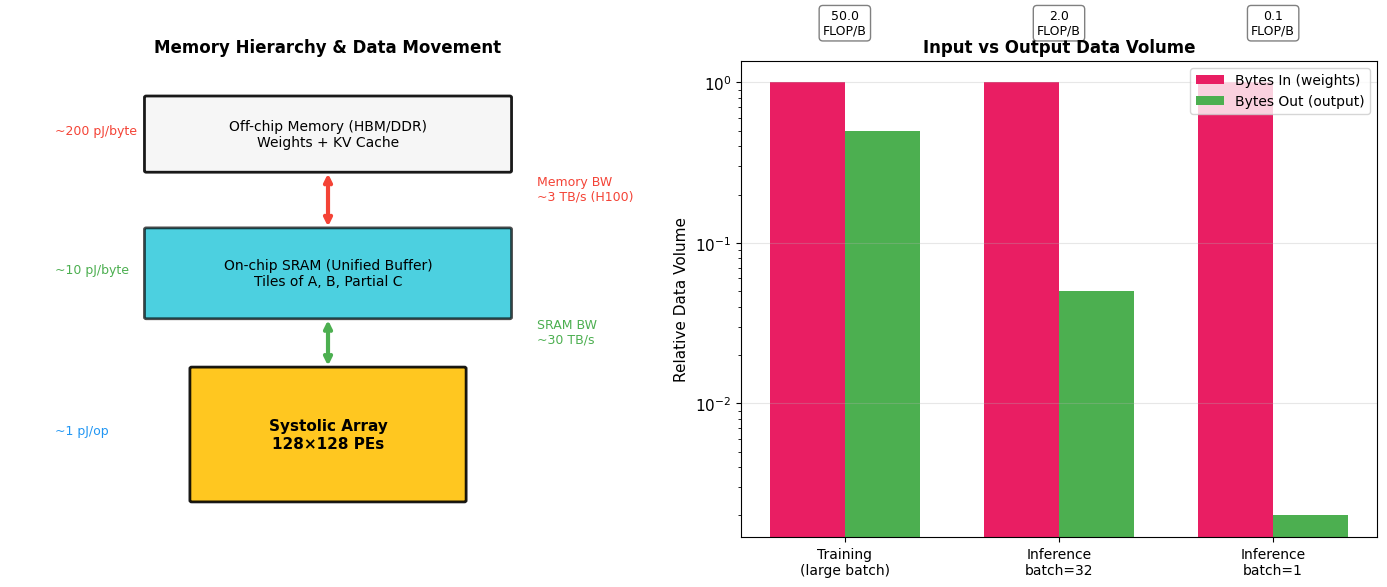


Key insight: For LLM inference with batch=1:
  - We read ~70B parameters (140GB in FP16)
  - We produce ~4KB output per token (one hidden state)
  - Ratio: ~35,000,000:1 input to output!
  - Almost all bandwidth is consumed reading weights, not writing results


In [8]:
# Visualize: Data movement in matrix multiplication
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Conceptual data flow
ax = axes[0]

# DRAM
dram = patches.FancyBboxPatch((0.5, 5), 4, 1,
                               boxstyle="round,pad=0.02",
                               facecolor=COLORS['light'], alpha=0.9,
                               edgecolor='black', linewidth=2)
ax.add_patch(dram)
ax.text(2.5, 5.5, 'Off-chip Memory (HBM/DDR)\nWeights + KV Cache', ha='center', va='center', fontsize=10)

# On-chip SRAM
sram = patches.FancyBboxPatch((0.5, 3), 4, 1.2,
                               boxstyle="round,pad=0.02",
                               facecolor=COLORS['cyan'], alpha=0.7,
                               edgecolor='black', linewidth=2)
ax.add_patch(sram)
ax.text(2.5, 3.6, 'On-chip SRAM (Unified Buffer)\nTiles of A, B, Partial C', ha='center', va='center', fontsize=10)

# Systolic Array
array = patches.FancyBboxPatch((1, 0.5), 3, 1.8,
                                boxstyle="round,pad=0.02",
                                facecolor=COLORS['pe'], alpha=0.9,
                                edgecolor='black', linewidth=2)
ax.add_patch(array)
ax.text(2.5, 1.4, 'Systolic Array\n128×128 PEs', ha='center', va='center', fontsize=11, fontweight='bold')

# Arrows with bandwidth labels
ax.annotate('', xy=(2.5, 4.2), xytext=(2.5, 5),
            arrowprops=dict(arrowstyle='<->', color=COLORS['danger'], lw=3))
ax.text(4.8, 4.6, 'Memory BW\n~3 TB/s (H100)', fontsize=9, color=COLORS['danger'])

ax.annotate('', xy=(2.5, 2.3), xytext=(2.5, 3),
            arrowprops=dict(arrowstyle='<->', color=COLORS['success'], lw=3))
ax.text(4.8, 2.65, 'SRAM BW\n~30 TB/s', fontsize=9, color=COLORS['success'])

# Add energy costs
ax.text(-0.5, 5.5, '~200 pJ/byte', fontsize=9, color=COLORS['danger'])
ax.text(-0.5, 3.6, '~10 pJ/byte', fontsize=9, color=COLORS['success'])
ax.text(-0.5, 1.4, '~1 pJ/op', fontsize=9, color=COLORS['primary'])

ax.set_xlim(-1, 6)
ax.set_ylim(0, 6.5)
ax.axis('off')
ax.set_title('Memory Hierarchy & Data Movement', fontsize=12, fontweight='bold')

# Right: Bytes in vs out for different operations
ax = axes[1]

# Different scenarios
scenarios = {
    'Training\n(large batch)': {'bytes_in': 1.0, 'bytes_out': 0.5, 'compute': 50},
    'Inference\nbatch=32': {'bytes_in': 1.0, 'bytes_out': 0.05, 'compute': 2},
    'Inference\nbatch=1': {'bytes_in': 1.0, 'bytes_out': 0.002, 'compute': 0.06},
}

x = np.arange(len(scenarios))
width = 0.35

bytes_in = [s['bytes_in'] for s in scenarios.values()]
bytes_out = [s['bytes_out'] for s in scenarios.values()]

bars1 = ax.bar(x - width/2, bytes_in, width, label='Bytes In (weights)', color=COLORS['weight'])
bars2 = ax.bar(x + width/2, bytes_out, width, label='Bytes Out (output)', color=COLORS['success'])

ax.set_ylabel('Relative Data Volume', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(scenarios.keys(), fontsize=10)
ax.legend(fontsize=10)
ax.set_title('Input vs Output Data Volume', fontsize=12, fontweight='bold')
ax.set_yscale('log')
ax.grid(True, alpha=0.3, axis='y')

# Add compute/byte ratio
for i, (name, s) in enumerate(scenarios.items()):
    ax.text(i, max(bytes_in[i], bytes_out[i]) * 2, 
            f"{s['compute']:.1f}\nFLOP/B", ha='center', fontsize=9,
            bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round'))

plt.tight_layout()
plt.show()

print("\nKey insight: For LLM inference with batch=1:")
print("  - We read ~70B parameters (140GB in FP16)")
print("  - We produce ~4KB output per token (one hidden state)")
print("  - Ratio: ~35,000,000:1 input to output!")
print("  - Almost all bandwidth is consumed reading weights, not writing results")

In [9]:
# Calculate: Detailed data movement for one transformer layer

def layer_data_movement(d_model, d_ff, n_heads, seq_len, batch_size, dtype_bytes=2):
    """Calculate data movement for one transformer layer."""
    
    d_head = d_model // n_heads
    
    # Input activations
    input_bytes = batch_size * seq_len * d_model * dtype_bytes
    
    # === Attention ===
    # QKV projection weights
    qkv_weight_bytes = 3 * d_model * d_model * dtype_bytes
    # QKV output (intermediate)
    qkv_output_bytes = 3 * batch_size * seq_len * d_model * dtype_bytes
    
    # Attention scores (not materialized with Flash Attention)
    # Without Flash: batch * n_heads * seq_len * seq_len * dtype_bytes
    # With Flash: only O(seq_len) per block
    attn_scores_flash = batch_size * n_heads * seq_len * 128 * dtype_bytes  # Block size 128
    
    # Output projection weights
    out_proj_weight_bytes = d_model * d_model * dtype_bytes
    
    # === FFN ===
    # Up/gate projection weights (SwiGLU has 2)
    ffn_up_weight_bytes = 2 * d_model * d_ff * dtype_bytes
    # Down projection weights
    ffn_down_weight_bytes = d_ff * d_model * dtype_bytes
    # FFN intermediate
    ffn_intermediate_bytes = batch_size * seq_len * d_ff * dtype_bytes
    
    # === Totals ===
    weight_bytes = qkv_weight_bytes + out_proj_weight_bytes + ffn_up_weight_bytes + ffn_down_weight_bytes
    activation_bytes = input_bytes + qkv_output_bytes + attn_scores_flash + ffn_intermediate_bytes
    
    # FLOPs
    # QKV projection: 3 × batch × seq × d_model × d_model × 2
    qkv_flops = 3 * 2 * batch_size * seq_len * d_model * d_model
    # Attention: batch × n_heads × (seq × seq × d_head × 2 for QK + seq × seq × d_head × 2 for AV)
    attn_flops = 2 * batch_size * n_heads * 2 * seq_len * seq_len * d_head
    # Out projection
    out_flops = 2 * batch_size * seq_len * d_model * d_model
    # FFN
    ffn_flops = 2 * batch_size * seq_len * d_model * d_ff * 3  # up, gate, down
    
    total_flops = qkv_flops + attn_flops + out_flops + ffn_flops
    
    return {
        'weight_bytes': weight_bytes,
        'activation_bytes': activation_bytes,
        'total_bytes': weight_bytes + activation_bytes,
        'total_flops': total_flops,
        'intensity': total_flops / (weight_bytes + activation_bytes),
        'weight_fraction': weight_bytes / (weight_bytes + activation_bytes),
    }

print("="*80)
print("DATA MOVEMENT PER TRANSFORMER LAYER (Llama 2 7B config)")
print("="*80)

# Llama 2 7B config
d_model = 4096
d_ff = 11008
n_heads = 32

configs = [
    (1, 1, "Inference batch=1, 1 token"),
    (1, 2048, "Inference batch=1, 2K context"),
    (32, 1, "Inference batch=32, 1 token"),
    (32, 2048, "Training batch=32, 2K seq"),
]

for batch, seq, name in configs:
    stats = layer_data_movement(d_model, d_ff, n_heads, seq, batch)
    print(f"\n{name}:")
    print(f"  Weight data: {stats['weight_bytes']/1e6:.1f} MB ({stats['weight_fraction']*100:.0f}% of total)")
    print(f"  Activation data: {stats['activation_bytes']/1e6:.1f} MB")
    print(f"  Total data: {stats['total_bytes']/1e6:.1f} MB")
    print(f"  Total FLOPs: {stats['total_flops']/1e9:.2f} GFLOPs")
    print(f"  Arithmetic intensity: {stats['intensity']:.1f} FLOP/byte")
    
    # Time estimate on H100
    h100_bw = 3.35e12  # bytes/s
    h100_compute = 990e12  # FLOPS
    time_bw_limited = stats['total_bytes'] / h100_bw * 1000  # ms
    time_compute_limited = stats['total_flops'] / h100_compute * 1000  # ms
    print(f"  H100 time: {max(time_bw_limited, time_compute_limited):.3f} ms "
          f"({'BW' if time_bw_limited > time_compute_limited else 'Compute'}-limited)")

DATA MOVEMENT PER TRANSFORMER LAYER (Llama 2 7B config)

Inference batch=1, 1 token:
  Weight data: 404.8 MB (100% of total)
  Activation data: 0.1 MB
  Total data: 404.8 MB
  Total FLOPs: 0.40 GFLOPs
  Arithmetic intensity: 1.0 FLOP/byte
  H100 time: 0.121 ms (BW-limited)

Inference batch=1, 2K context:
  Weight data: 404.8 MB (76% of total)
  Activation data: 129.0 MB
  Total data: 533.7 MB
  Total FLOPs: 897.65 GFLOPs
  Arithmetic intensity: 1681.9 FLOP/byte
  H100 time: 0.907 ms (Compute-limited)

Inference batch=32, 1 token:
  Weight data: 404.8 MB (100% of total)
  Activation data: 2.0 MB
  Total data: 406.8 MB
  Total FLOPs: 12.95 GFLOPs
  Arithmetic intensity: 31.8 FLOP/byte
  H100 time: 0.121 ms (BW-limited)

Training batch=32, 2K seq:
  Weight data: 404.8 MB (9% of total)
  Activation data: 4127.2 MB
  Total data: 4531.9 MB
  Total FLOPs: 28724.74 GFLOPs
  Arithmetic intensity: 6338.3 FLOP/byte
  H100 time: 29.015 ms (Compute-limited)


---

<a id='memory-hierarchy'></a>
## 7. Memory Hierarchy and Data Reuse

Efficient accelerators maximize **data reuse** to minimize expensive off-chip memory access.

### Types of Data Reuse in Matrix Multiply

| Reuse Type | Description | Systolic Array Benefit |
|------------|-------------|------------------------|
| **Temporal** | Same data used multiple times | Accumulators stay in PE |
| **Spatial-A** | A elements shared across columns | A flows right through array |
| **Spatial-B** | B elements shared across rows | B flows down through array |

### The On-Chip Memory Budget

For a 128×128 systolic array:
- **Minimum**: 2 tiles × (128×128) × 2 bytes = 64 KB (just A and B)
- **Practical**: Need input FIFOs, output buffers, double buffering
- **TPU v4**: ~32 MB on-chip SRAM

### Double Buffering

To hide memory latency:
1. While computing tile (i, j), load tile (i, j+1)
2. Requires 2× tile storage
3. Achieves near-100% compute utilization

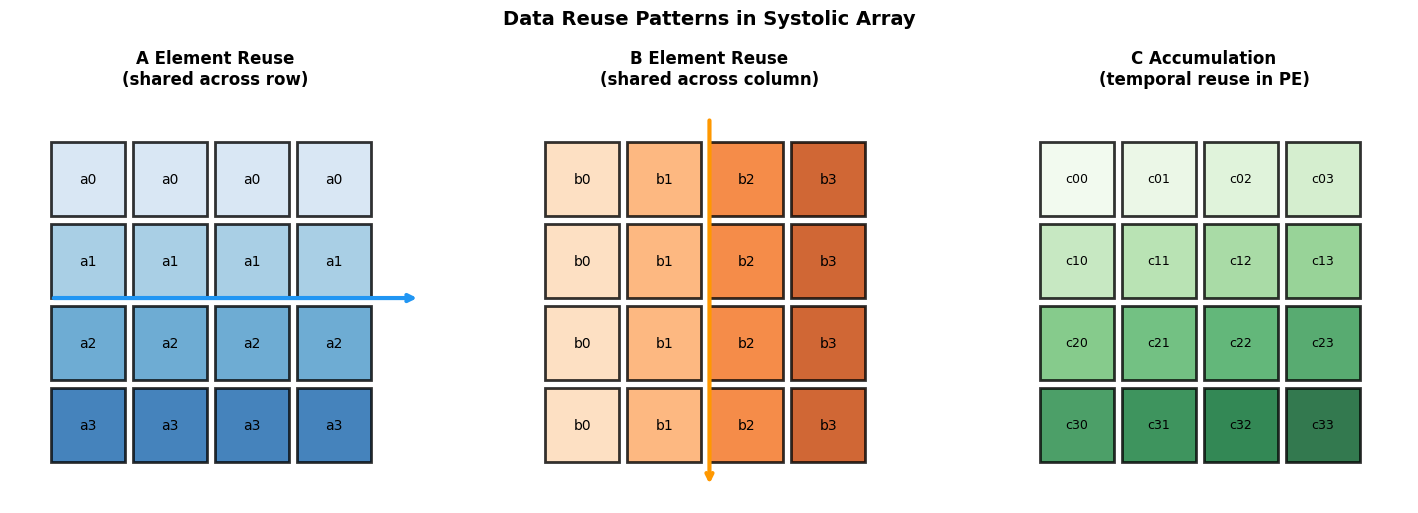

For P×P array computing P×K × K×P:
  Each A element reused P times (across columns)
  Each B element reused P times (across rows)
  Each C accumulator updated K times (temporal reuse)

This is why systolic arrays achieve high efficiency!


In [10]:
# Visualize: Data reuse patterns in systolic array
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

def draw_reuse_pattern(ax, pattern_type):
    """Draw data reuse pattern."""
    n = 4
    
    for i in range(n):
        for j in range(n):
            x, y = j, n - 1 - i
            
            if pattern_type == 'A':
                # Same row = same A element
                color = plt.cm.Blues((i + 1) / (n + 1))
            elif pattern_type == 'B':
                # Same column = same B element
                color = plt.cm.Oranges((j + 1) / (n + 1))
            else:
                # Accumulator - each PE unique
                color = plt.cm.Greens(((i * n + j) + 1) / (n * n + 1))
            
            rect = patches.Rectangle((x, y), 0.9, 0.9,
                                      facecolor=color, alpha=0.8,
                                      edgecolor='black', linewidth=2)
            ax.add_patch(rect)
            
            if pattern_type == 'A':
                ax.text(x + 0.45, y + 0.45, f'a{i}', ha='center', va='center', fontsize=10)
            elif pattern_type == 'B':
                ax.text(x + 0.45, y + 0.45, f'b{j}', ha='center', va='center', fontsize=10)
            else:
                ax.text(x + 0.45, y + 0.45, f'c{i}{j}', ha='center', va='center', fontsize=9)
    
    ax.set_xlim(-0.5, n + 0.5)
    ax.set_ylim(-0.5, n + 0.5)
    ax.set_aspect('equal')
    ax.axis('off')

# A reuse (spatial across columns)
draw_reuse_pattern(axes[0], 'A')
axes[0].set_title('A Element Reuse\n(shared across row)', fontsize=12, fontweight='bold')
axes[0].annotate('', xy=(4.5, 2), xytext=(0, 2),
                 arrowprops=dict(arrowstyle='->', color=COLORS['primary'], lw=3))

# B reuse (spatial across rows)
draw_reuse_pattern(axes[1], 'B')
axes[1].set_title('B Element Reuse\n(shared across column)', fontsize=12, fontweight='bold')
axes[1].annotate('', xy=(2, -0.3), xytext=(2, 4.2),
                 arrowprops=dict(arrowstyle='->', color=COLORS['secondary'], lw=3))

# C accumulation (temporal reuse)
draw_reuse_pattern(axes[2], 'C')
axes[2].set_title('C Accumulation\n(temporal reuse in PE)', fontsize=12, fontweight='bold')

plt.suptitle('Data Reuse Patterns in Systolic Array', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("For P×P array computing P×K × K×P:")
print(f"  Each A element reused P times (across columns)")
print(f"  Each B element reused P times (across rows)")
print(f"  Each C accumulator updated K times (temporal reuse)")
print(f"\nThis is why systolic arrays achieve high efficiency!")

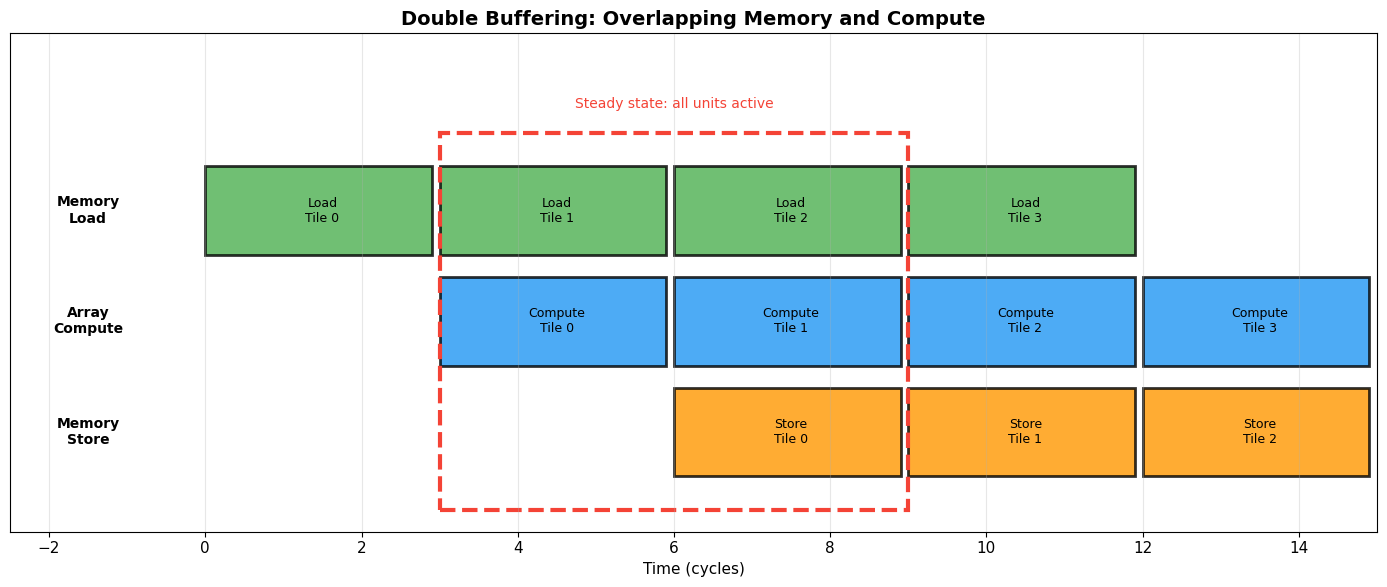

Without double buffering: Load → Compute → Store (serial)
With double buffering: Load/Compute/Store overlap (pipelined)

Requirement: 2× buffer memory to hold current and next tile


In [11]:
# Visualize: Double buffering concept
fig, ax = plt.subplots(figsize=(14, 6))

# Timeline
cycles = 12
tile_time = 3

# Memory load (green)
for i in range(4):
    start = i * tile_time
    rect = patches.Rectangle((start, 2), tile_time - 0.1, 0.8,
                              facecolor=COLORS['success'], alpha=0.8,
                              edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    ax.text(start + tile_time/2, 2.4, f'Load\nTile {i}', ha='center', va='center', fontsize=9)

# Compute (blue) - starts after first load
for i in range(4):
    start = tile_time + i * tile_time
    rect = patches.Rectangle((start, 1), tile_time - 0.1, 0.8,
                              facecolor=COLORS['primary'], alpha=0.8,
                              edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    ax.text(start + tile_time/2, 1.4, f'Compute\nTile {i}', ha='center', va='center', fontsize=9)

# Store (orange) - starts after first compute
for i in range(4):
    start = 2 * tile_time + i * tile_time
    if start < cycles + 3:
        rect = patches.Rectangle((start, 0), tile_time - 0.1, 0.8,
                                  facecolor=COLORS['secondary'], alpha=0.8,
                                  edgecolor='black', linewidth=2)
        ax.add_patch(rect)
        ax.text(start + tile_time/2, 0.4, f'Store\nTile {i}', ha='center', va='center', fontsize=9)

# Labels
ax.text(-1.5, 2.4, 'Memory\nLoad', ha='center', va='center', fontsize=10, fontweight='bold')
ax.text(-1.5, 1.4, 'Array\nCompute', ha='center', va='center', fontsize=10, fontweight='bold')
ax.text(-1.5, 0.4, 'Memory\nStore', ha='center', va='center', fontsize=10, fontweight='bold')

# Highlight overlap
rect = patches.Rectangle((tile_time, -0.3), 2*tile_time, 3.4,
                          facecolor='none', edgecolor=COLORS['danger'],
                          linewidth=3, linestyle='--')
ax.add_patch(rect)
ax.text(tile_time + tile_time, 3.3, 'Steady state: all units active', 
        ha='center', va='bottom', fontsize=10, color=COLORS['danger'])

ax.set_xlim(-2.5, 15)
ax.set_ylim(-0.5, 4)
ax.set_xlabel('Time (cycles)', fontsize=11)
ax.set_title('Double Buffering: Overlapping Memory and Compute', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.set_yticks([])

plt.tight_layout()
plt.show()

print("Without double buffering: Load → Compute → Store (serial)")
print("With double buffering: Load/Compute/Store overlap (pipelined)")
print("\nRequirement: 2× buffer memory to hold current and next tile")

---

<a id='mapping-transformers'></a>
## 8. Mapping Transformers to Systolic Arrays

Now let's see how actual transformer operations map to systolic array execution.

### Operation Mapping

| Transformer Op | Matrix Shape | Systolic Mapping | Notes |
|----------------|--------------|------------------|-------|
| QKV Projection | (B×S, d) × (d, 3d) | GEMM | Fused as one op |
| Attention QK^T | (B×H, S, d_h) × (B×H, d_h, S) | Batched GEMM | Per head |
| Attention × V | (B×H, S, S) × (B×H, S, d_h) | Batched GEMM | Per head |
| Out Projection | (B×S, d) × (d, d) | GEMM | |
| FFN Up | (B×S, d) × (d, 4d) | GEMM | |
| FFN Down | (B×S, 4d) × (4d, d) | GEMM | |

### The Special Case: Inference with Batch=1

During autoregressive generation:
- Only processing one new token at a time
- Input is (1, d) not (B×S, d)
- GEMM becomes GEMV (matrix-vector)

This fundamentally changes the arithmetic intensity:

| Operation | Training/Prefill | Inference (B=1) |
|-----------|------------------|------------------|
| Shape | (B×S, d) × (d, k) | (1, d) × (d, k) |
| FLOPs | 2 × B × S × d × k | 2 × d × k |
| Bytes | ≈ d × k × 2 (weights) | d × k × 2 (weights) |
| Intensity | ~B×S (high) | ~1 (very low) |

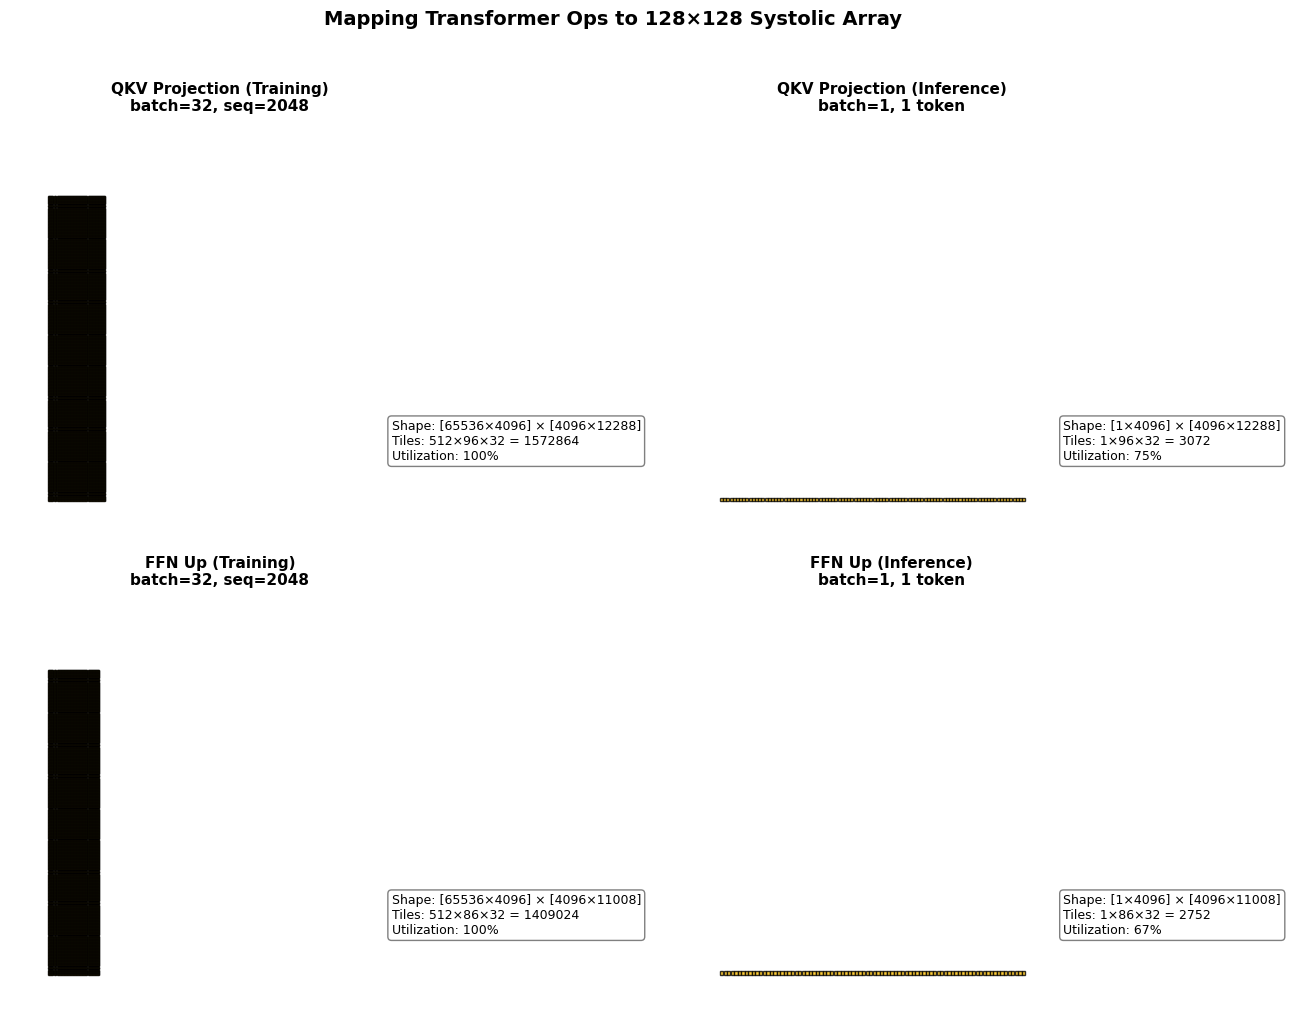


Critical observation:
  Training: Large batch fills the array efficiently
  Inference: Only 1 row of the array is used!
  → 128×128 = 16,384 PEs, but only 128 active = 0.8% utilization

This is why inference is memory-bound, not compute-bound.


In [12]:
# Visualize: Mapping transformer operations to systolic array
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

def draw_gemm_on_array(ax, M, N, K, array_size, title):
    """Draw how a GEMM maps to systolic array."""
    P = array_size
    
    # Calculate tiles
    m_tiles = (M + P - 1) // P
    n_tiles = (N + P - 1) // P
    k_tiles = (K + P - 1) // P
    
    # Draw array utilization grid
    max_dim = max(m_tiles, n_tiles)
    cell_size = 4.0 / max(max_dim, 1)
    
    for i in range(m_tiles):
        for j in range(n_tiles):
            x = j * cell_size
            y = (m_tiles - 1 - i) * cell_size
            
            rect = patches.Rectangle((x, y), cell_size * 0.95, cell_size * 0.95,
                                      facecolor=COLORS['pe'], alpha=0.8,
                                      edgecolor='black', linewidth=1)
            ax.add_patch(rect)
    
    # Stats
    total_tiles = m_tiles * n_tiles * k_tiles
    
    # Handle edge case where dimensions are smaller than array
    if M < P or N < P:
        utilization = (M * N) / (P * P) * 100
    else:
        utilization = 100  # Full tiles
    
    ax.set_xlim(-0.5, 5)
    ax.set_ylim(-0.5, 5)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=11, fontweight='bold')
    
    # Add info text
    info = f"Shape: [{M}×{K}] × [{K}×{N}]\n"
    info += f"Tiles: {m_tiles}×{n_tiles}×{k_tiles} = {total_tiles}\n"
    info += f"Utilization: {utilization:.0f}%"
    ax.text(4.5, 0.5, info, fontsize=9, va='bottom', ha='left',
            bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round'))

# Llama 2 7B ops with 128×128 array
P = 128

# QKV projection (training, batch=32, seq=2048)
draw_gemm_on_array(axes[0, 0], 32*2048, 12288, 4096, P, 
                   'QKV Projection (Training)\nbatch=32, seq=2048')

# QKV projection (inference, batch=1, 1 token)
draw_gemm_on_array(axes[0, 1], 1, 12288, 4096, P,
                   'QKV Projection (Inference)\nbatch=1, 1 token')

# FFN (training)
draw_gemm_on_array(axes[1, 0], 32*2048, 11008, 4096, P,
                   'FFN Up (Training)\nbatch=32, seq=2048')

# FFN (inference)
draw_gemm_on_array(axes[1, 1], 1, 11008, 4096, P,
                   'FFN Up (Inference)\nbatch=1, 1 token')

plt.suptitle('Mapping Transformer Ops to 128×128 Systolic Array', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nCritical observation:")
print("  Training: Large batch fills the array efficiently")
print("  Inference: Only 1 row of the array is used!")
print("  → 128×128 = 16,384 PEs, but only 128 active = 0.8% utilization")
print("\nThis is why inference is memory-bound, not compute-bound.")

In [13]:
# Calculate: Complete inference pass data movement

def full_inference_analysis(d_model, n_layers, d_ff, n_heads, vocab_size, 
                           seq_len, dtype_bytes=2):
    """Analyze complete inference pass for one token."""
    
    d_head = d_model // n_heads
    
    # === Weights (read from memory) ===
    
    # Per-layer weights
    qkv_weights = 3 * d_model * d_model * dtype_bytes
    out_proj_weights = d_model * d_model * dtype_bytes
    ffn_up_weights = 2 * d_model * d_ff * dtype_bytes  # gate + up
    ffn_down_weights = d_ff * d_model * dtype_bytes
    layer_weights = qkv_weights + out_proj_weights + ffn_up_weights + ffn_down_weights
    
    total_layer_weights = layer_weights * n_layers
    
    # Embedding + output projection
    embed_weights = vocab_size * d_model * dtype_bytes
    output_weights = d_model * vocab_size * dtype_bytes  # Often tied
    
    total_weights = total_layer_weights + embed_weights
    
    # === KV Cache (read existing, write new) ===
    # For each layer, read seq_len KV pairs, write 1 new pair
    kv_read = n_layers * 2 * seq_len * d_model * dtype_bytes
    kv_write = n_layers * 2 * 1 * d_model * dtype_bytes
    
    # === Activations (mostly on-chip) ===
    # Input embedding: 1 × d_model
    # Between layers: 1 × d_model
    activation_per_layer = d_model * dtype_bytes  # Very small!
    
    # === FLOPs ===
    # Per layer:
    qkv_flops = 3 * 2 * 1 * d_model * d_model
    attn_qk_flops = 2 * n_heads * 1 * seq_len * d_head  # New Q against all K
    attn_v_flops = 2 * n_heads * 1 * seq_len * d_head   # Weights × V
    out_flops = 2 * 1 * d_model * d_model
    ffn_flops = 3 * 2 * 1 * d_model * d_ff  # gate + up + down
    layer_flops = qkv_flops + attn_qk_flops + attn_v_flops + out_flops + ffn_flops
    
    total_flops = layer_flops * n_layers + 2 * d_model * vocab_size  # + output projection
    
    # === Summary ===
    total_read = total_weights + kv_read
    total_write = kv_write + d_model * dtype_bytes  # output hidden state
    
    return {
        'total_weights_gb': total_weights / 1e9,
        'kv_read_gb': kv_read / 1e9,
        'kv_write_bytes': kv_write,
        'total_read_gb': total_read / 1e9,
        'total_write_mb': total_write / 1e6,
        'total_flops_gflops': total_flops / 1e9,
        'arithmetic_intensity': total_flops / (total_read + total_write),
        'read_write_ratio': total_read / total_write,
    }

print("="*80)
print("COMPLETE INFERENCE ANALYSIS: One Token Generation")
print("="*80)

# Llama 2 7B
config_7b = {
    'd_model': 4096, 'n_layers': 32, 'd_ff': 11008, 
    'n_heads': 32, 'vocab_size': 32000
}

for seq_len in [1, 512, 2048, 8192]:
    stats = full_inference_analysis(**config_7b, seq_len=seq_len)
    print(f"\nLlama 2 7B, context length = {seq_len}:")
    print(f"  Weights read: {stats['total_weights_gb']:.2f} GB")
    print(f"  KV cache read: {stats['kv_read_gb']:.4f} GB ({stats['kv_read_gb']/stats['total_read_gb']*100:.1f}% of reads)")
    print(f"  Total read: {stats['total_read_gb']:.2f} GB")
    print(f"  Total write: {stats['total_write_mb']:.3f} MB")
    print(f"  Read:Write ratio: {stats['read_write_ratio']:.0f}:1")
    print(f"  FLOPs: {stats['total_flops_gflops']:.1f} GFLOPs")
    print(f"  Arithmetic intensity: {stats['arithmetic_intensity']:.2f} FLOP/byte")
    
    # Time estimate
    h100_bw = 3.35e12  # bytes/s
    time_ms = stats['total_read_gb'] * 1e9 / h100_bw * 1000
    tokens_per_sec = 1000 / time_ms
    print(f"  H100 time: {time_ms:.2f} ms → {tokens_per_sec:.0f} tokens/s")

COMPLETE INFERENCE ANALYSIS: One Token Generation

Llama 2 7B, context length = 1:
  Weights read: 13.21 GB
  KV cache read: 0.0005 GB (0.0% of reads)
  Total read: 13.21 GB
  Total write: 0.532 MB
  Read:Write ratio: 24817:1
  FLOPs: 13.2 GFLOPs
  Arithmetic intensity: 1.00 FLOP/byte
  H100 time: 3.94 ms → 254 tokens/s

Llama 2 7B, context length = 512:
  Weights read: 13.21 GB
  KV cache read: 0.2684 GB (2.0% of reads)
  Total read: 13.48 GB
  Total write: 0.532 MB
  Read:Write ratio: 25320:1
  FLOPs: 13.5 GFLOPs
  Arithmetic intensity: 1.00 FLOP/byte
  H100 time: 4.02 ms → 248 tokens/s

Llama 2 7B, context length = 2048:
  Weights read: 13.21 GB
  KV cache read: 1.0737 GB (7.5% of reads)
  Total read: 14.29 GB
  Total write: 0.532 MB
  Read:Write ratio: 26833:1
  FLOPs: 14.3 GFLOPs
  Arithmetic intensity: 1.00 FLOP/byte
  H100 time: 4.27 ms → 234 tokens/s

Llama 2 7B, context length = 8192:
  Weights read: 13.21 GB
  KV cache read: 4.2950 GB (24.5% of reads)
  Total read: 17.51 GB
 

---

<a id='why-superconducting'></a>
## 9. Why Superconducting Logic?

We've now established the fundamental problem:

### The Memory Bandwidth Crisis

| Factor | Value |
|--------|-------|
| Model size (Llama 70B, FP16) | 140 GB |
| H100 memory bandwidth | 3.35 TB/s |
| Maximum tokens/sec (70B) | ~24 |
| H100 compute capability | 990 TFLOPS |
| Actual utilization (batch=1) | ~1% |

**The hardware is 99% idle because we can't feed it data fast enough!**

### Potential Solutions

| Approach | Challenge |
|----------|----------|
| More memory bandwidth | Approaching physical limits, high power |
| Larger batch sizes | Requires proportionally more memory |
| Model compression | Quality loss, diminishing returns |
| Compute-in-memory | Analog noise, limited precision |
| **Superconducting logic** | Operating temperature, fabrication |

### The Superconducting Advantage

Superconducting electronics offer a unique combination:

1. **Ultra-low switching energy**: ~10⁻¹⁹ J vs 10⁻¹⁵ J for CMOS
2. **High speed**: Natural clock frequencies of 10-100 GHz
3. **Dense integration**: Less heat to remove → more compute per mm²
4. **Native compatibility with cryo-memory**: HBM at 4K has higher bandwidth

The vision: Put the entire model **on-chip** in superconducting SRAM, eliminating the memory bandwidth bottleneck entirely.

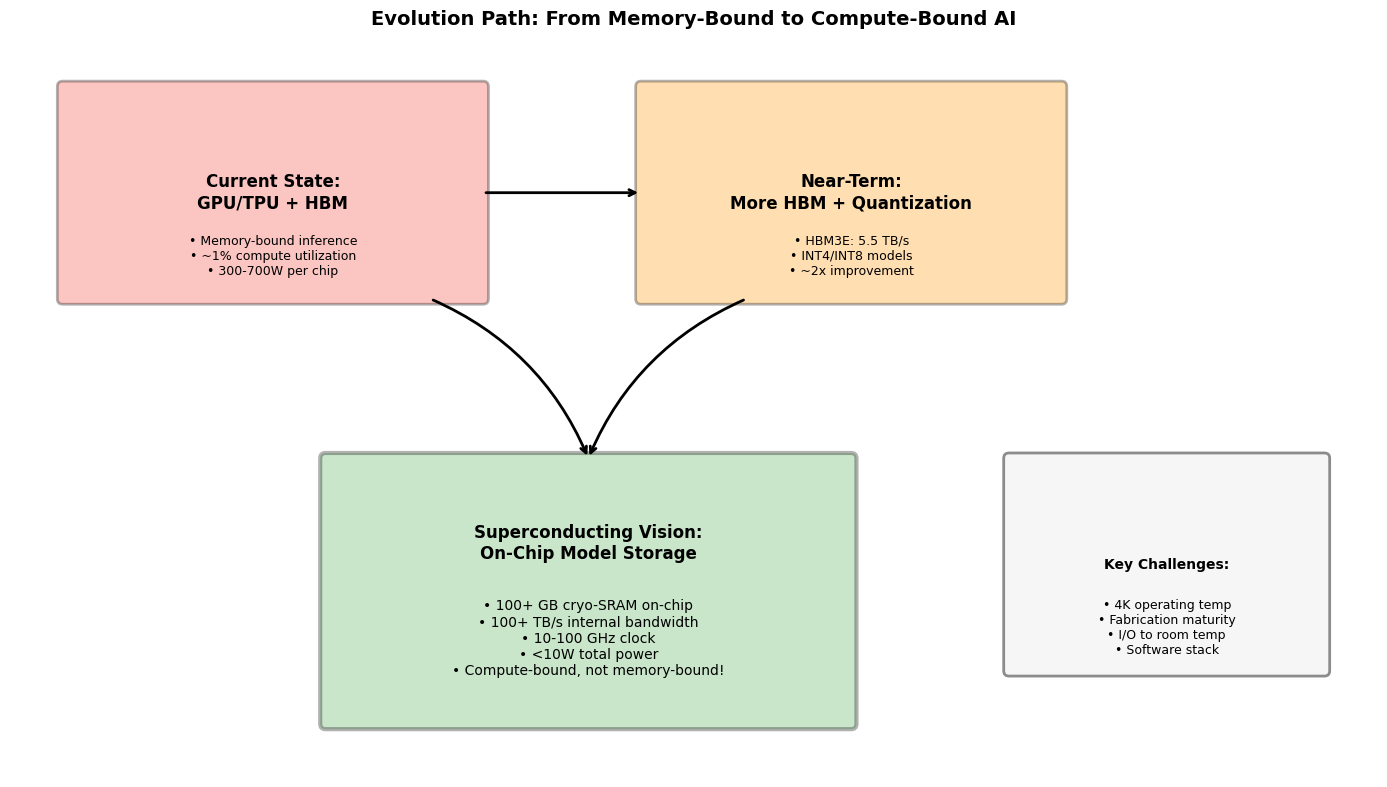

The fundamental insight:
  Current accelerators are starving for data.
  Superconducting logic enables putting the model ON the chip.
  This transforms the problem from memory-bound to compute-bound.

At 4K, we can integrate:
  • Dense SRAM (no refresh needed)
  • High-speed logic (100 GHz possible)
  • Extreme energy efficiency (<1 aJ per operation)


In [14]:
# Visualize: The path from conventional to superconducting accelerators
fig, ax = plt.subplots(figsize=(14, 8))

# Current state
current = patches.FancyBboxPatch((0.5, 5.5), 4, 2,
                                  boxstyle="round,pad=0.05",
                                  facecolor=COLORS['danger'], alpha=0.3,
                                  edgecolor='black', linewidth=2)
ax.add_patch(current)
ax.text(2.5, 6.5, 'Current State:\nGPU/TPU + HBM', ha='center', va='center', fontsize=12, fontweight='bold')
ax.text(2.5, 5.9, '• Memory-bound inference\n• ~1% compute utilization\n• 300-700W per chip', 
        ha='center', va='center', fontsize=9)

# Near-term improvements
near = patches.FancyBboxPatch((6, 5.5), 4, 2,
                               boxstyle="round,pad=0.05",
                               facecolor=COLORS['secondary'], alpha=0.3,
                               edgecolor='black', linewidth=2)
ax.add_patch(near)
ax.text(8, 6.5, 'Near-Term:\nMore HBM + Quantization', ha='center', va='center', fontsize=12, fontweight='bold')
ax.text(8, 5.9, '• HBM3E: 5.5 TB/s\n• INT4/INT8 models\n• ~2x improvement', 
        ha='center', va='center', fontsize=9)

# Superconducting vision
sce = patches.FancyBboxPatch((3, 1.5), 5, 2.5,
                              boxstyle="round,pad=0.05",
                              facecolor=COLORS['success'], alpha=0.3,
                              edgecolor='black', linewidth=3)
ax.add_patch(sce)
ax.text(5.5, 3.2, 'Superconducting Vision:\nOn-Chip Model Storage', ha='center', va='center', 
        fontsize=12, fontweight='bold')
ax.text(5.5, 2.3, '• 100+ GB cryo-SRAM on-chip\n• 100+ TB/s internal bandwidth\n• 10-100 GHz clock\n• <10W total power\n• Compute-bound, not memory-bound!', 
        ha='center', va='center', fontsize=10)

# Arrows
ax.annotate('', xy=(6, 6.5), xytext=(4.5, 6.5),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax.annotate('', xy=(5.5, 4), xytext=(4, 5.5),
            arrowprops=dict(arrowstyle='->', color='black', lw=2, connectionstyle='arc3,rad=-0.2'))
ax.annotate('', xy=(5.5, 4), xytext=(7, 5.5),
            arrowprops=dict(arrowstyle='->', color='black', lw=2, connectionstyle='arc3,rad=0.2'))

# Challenge callout
challenge = patches.FancyBboxPatch((9.5, 2), 3, 2,
                                    boxstyle="round,pad=0.05",
                                    facecolor=COLORS['light'], alpha=0.9,
                                    edgecolor='gray', linewidth=2)
ax.add_patch(challenge)
ax.text(11, 3, 'Key Challenges:', ha='center', va='center', fontsize=10, fontweight='bold')
ax.text(11, 2.4, '• 4K operating temp\n• Fabrication maturity\n• I/O to room temp\n• Software stack', 
        ha='center', va='center', fontsize=9)

ax.set_xlim(0, 13)
ax.set_ylim(1, 8)
ax.axis('off')
ax.set_title('Evolution Path: From Memory-Bound to Compute-Bound AI', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("The fundamental insight:")
print("  Current accelerators are starving for data.")
print("  Superconducting logic enables putting the model ON the chip.")
print("  This transforms the problem from memory-bound to compute-bound.")
print("\nAt 4K, we can integrate:")
print("  • Dense SRAM (no refresh needed)")
print("  • High-speed logic (100 GHz possible)")
print("  • Extreme energy efficiency (<1 aJ per operation)")

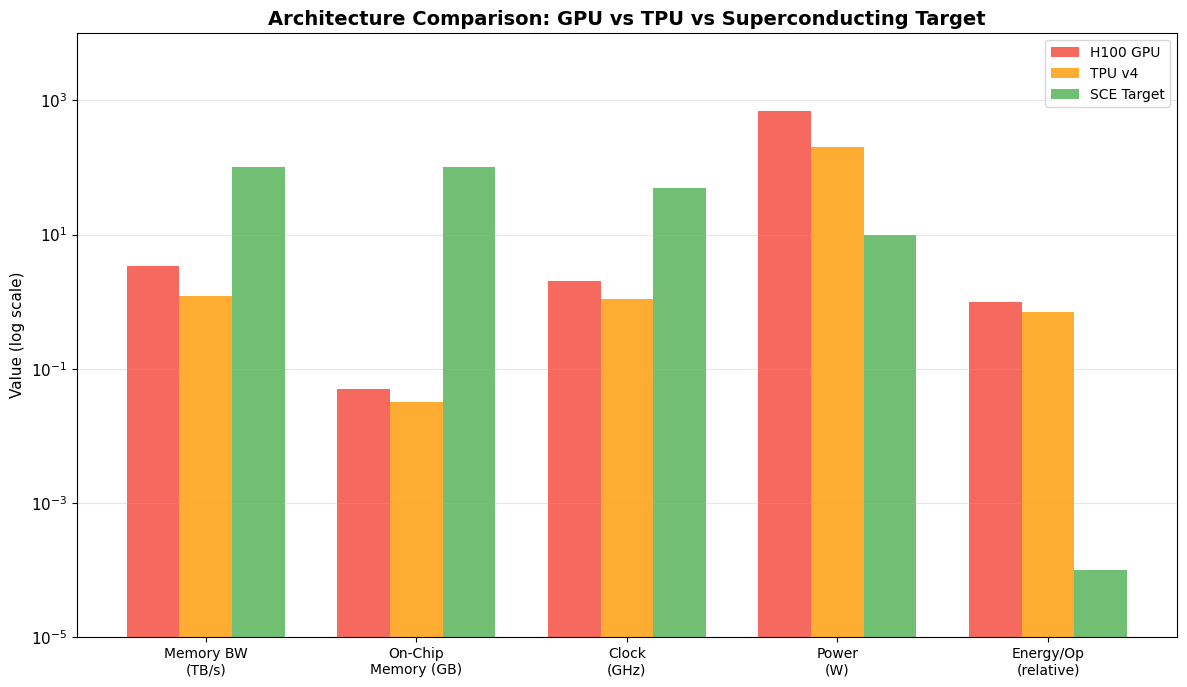


Superconducting electronics target advantages:
  • 30-100× memory bandwidth (on-chip)
  • 2000× on-chip memory
  • 25-50× clock frequency
  • 70× lower power
  • 10,000× lower energy per operation

These numbers enable fundamentally different system architectures.


In [15]:
# Visualize: Comparison of architectures
fig, ax = plt.subplots(figsize=(12, 7))

# Metrics comparison
categories = ['Memory BW\n(TB/s)', 'On-Chip\nMemory (GB)', 'Clock\n(GHz)', 'Power\n(W)', 'Energy/Op\n(relative)']

# Normalize to 0-1 scale for radar-like bar chart
systems = {
    'H100 GPU': [3.35, 0.05, 2.0, 700, 1.0],  # 50MB cache, 2GHz boost, 700W, baseline energy
    'TPU v4': [1.2, 0.032, 1.1, 200, 0.7],    # 32MB SRAM, 1.1GHz, 200W
    'SCE Target': [100, 100, 50, 10, 0.0001], # Vision: 100TB/s internal, 100GB SRAM, 50GHz, 10W
}

# Plot as grouped bar chart
x = np.arange(len(categories))
width = 0.25
multiplier = 0

colors = [COLORS['danger'], COLORS['secondary'], COLORS['success']]

for i, (name, values) in enumerate(systems.items()):
    # Log scale for visualization
    log_values = [np.log10(v + 0.0001) for v in values]
    # Normalize to positive range
    offset = x + width * multiplier
    rects = ax.bar(offset, values, width, label=name, color=colors[i], alpha=0.8)
    multiplier += 1

ax.set_ylabel('Value (log scale)', fontsize=11)
ax.set_yscale('log')
ax.set_xticks(x + width)
ax.set_xticklabels(categories, fontsize=10)
ax.legend(loc='upper right', fontsize=10)
ax.set_title('Architecture Comparison: GPU vs TPU vs Superconducting Target', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(1e-5, 1e4)

plt.tight_layout()
plt.show()

print("\nSuperconducting electronics target advantages:")
print("  • 30-100× memory bandwidth (on-chip)")
print("  • 2000× on-chip memory")
print("  • 25-50× clock frequency")
print("  • 70× lower power")
print("  • 10,000× lower energy per operation")
print("\nThese numbers enable fundamentally different system architectures.")

---

<a id='summary'></a>
## 10. Summary

<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%); padding: 30px; border-radius: 10px; color: white;">

### Key Concepts

**Systolic Arrays:**
- Regular grid of processing elements performing MAC operations
- Data flows through array, maximizing reuse
- Each element of A reused P times, each element of B reused P times
- Arithmetic intensity = P / bytes_per_element

**Tiling Large Matrices:**
- Split M×K × K×N into tiles that fit the P×P array
- Accumulate partial results across K-dimension tiles
- Double buffering hides memory latency

**Data Movement Analysis:**
- Inference (batch=1): Read entire model, produce tiny output
- Read:Write ratio can exceed 10,000,000:1
- Memory bandwidth is the bottleneck, not compute

**The Superconducting Opportunity:**
- Put entire model on-chip in cryo-SRAM
- Transform memory-bound → compute-bound
- Enable 10-100 GHz operation at milliwatt power

### Connection to Course

This lecture explains *why* superconducting electronics matter for AI:
- The memory wall is a fundamental physics problem
- Conventional scaling (Moore's Law) can't solve it
- Superconducting logic offers a path to 1000× efficiency

The previous lectures (AQFP, majority gates, fabrication) show *how* to build it.

</div>

### Key Numbers to Remember

| Metric | Value |
|--------|-------|
| TPU v4 array size | 128 × 128 = 16,384 MACs |
| Inference arithmetic intensity (batch=1) | ~2 FLOP/byte |
| H100 ridge point | ~300 FLOP/byte |
| H100 inference utilization | ~1% |
| Read:Write ratio (LLM inference) | >1,000,000:1 |
| Llama 70B tokens/s (H100, batch=1) | ~24 |